[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kushalpanthi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kushalpanthi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Accuracy: 0.7027027027027027
Classification Report:
               precision    recall  f1-score   support

        Fake       0.72      0.68      0.70        19
        Real       0.68      0.72      0.70        18

    accuracy                           0.70        37
   macro avg       0.70      0.70      0.70        37
weighted avg       0.70      0.70      0.70        37



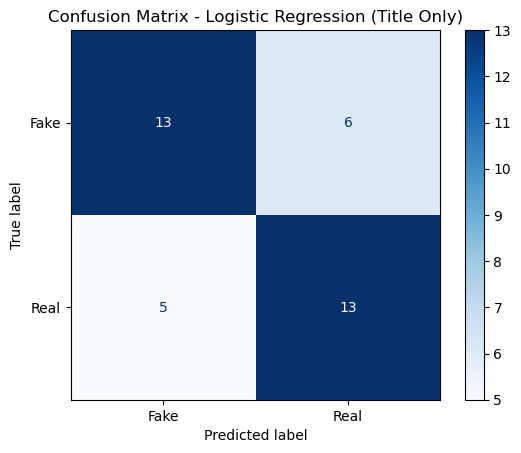

Enter news title:  what a histroy it will be 


Predicted News Type: Real


In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from data_preprocessing_module import preprocess_text  # custom preprocessing function

# Load data
df = pd.read_csv('datasets/changed/data_news_1.csv')

# Handle missing values in title
df['title'] = df['title'].fillna('Unknown')

# Apply preprocessing to title only
df['title_clean'] = df['title'].apply(preprocess_text)

# TF-IDF Vectorization on title only
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['title_clean'])

# Target variable
y = df['type_of_news']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Logistic Regression Model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Evaluate Model
y_pred = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Fake', 'Real'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression (Title Only)")
plt.show()

# User Input Prediction
user_title = input("Enter news title: ")
cleaned_title = preprocess_text(user_title)
user_vector = vectorizer.transform([cleaned_title])

prediction = lr_model.predict(user_vector)
print("Predicted News Type:", prediction[0])


#Change in accuracy was seen when changing to TF-IDF to regular countvectorization as the countvectorization just counts the word frequency while F-IDF goes beyond simple word counts by weighting words based on their importance

Accuracy: 0.8648648648648649
Classification Report:
               precision    recall  f1-score   support

        Fake       0.89      0.84      0.86        19
        Real       0.84      0.89      0.86        18

    accuracy                           0.86        37
   macro avg       0.87      0.87      0.86        37
weighted avg       0.87      0.86      0.86        37



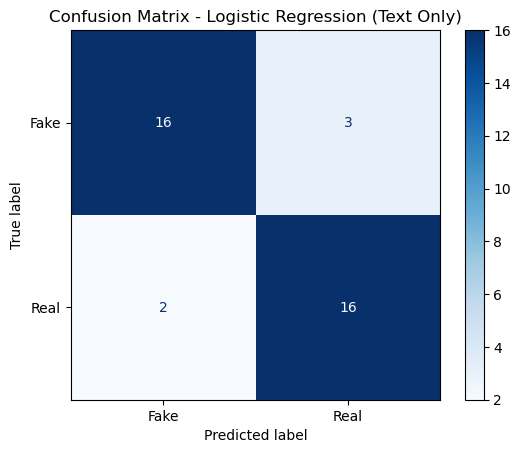

Enter news text:  This is follow up witht he text written tin the paragraph of the diabolical statemnt


Predicted News Type: Fake


In [3]:

#Now analyzing text

# Handle missing values in title
df['text'] = df['text'].fillna('Unknown')

# Apply preprocessing to title only
df['text_clean'] = df['text'].apply(preprocess_text)

# TF-IDF Vectorization on title only
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['text_clean'])

# Target variable
y = df['type_of_news']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Logistic Regression Model
lr_model_text = LogisticRegression()
lr_model_text.fit(X_train, y_train)

# Evaluate Model
y_pred = lr_model_text.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Fake', 'Real'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression (Text Only)")
plt.show()

# User Input Prediction
user_text = input("Enter news text: ")
cleaned_text = preprocess_text(user_text)
user_vector = vectorizer.transform([cleaned_text])

prediction = lr_model_text.predict(user_vector)
print("Predicted News Type:", prediction[0])
